# COGS 108 - Using Advanced Basketball Team Metrics to Predict NBA Championships (Group 108)

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [`X`] YES - make available
* [  ] NO - keep private

# Names

- Borngreat Omoma-Edosa
- Nhan Trac Teng
- Adrian Kong
- Dominic Loschiavo

# Abstract

Our project aimed to answer the question of which advanced basketball team metrics best predict NBA championship success. We noticed most predictors rely on subjective indicators like betting odds and MVP votes, so we focused on objective team performance statistics—such as offensive and defensive ratings, net rating. During our research we found “Four Factors” from Dean Oliver of effective field goal percentage, turnover rate, rebounding percentage, and free throw rate to offer a clearer, data-driven insight into what separates championship-caliber teams from the rest. From this info, we hypothesized that teams with higher net ratings and elite performance metrics (win shares and PER) are more likely to win the championship.

To achieve this, we compiled a comprehensive dataset from 1980 to 2024 NBA seasons by merging team-level advanced statistics from Basketball Reference with playoff outcome data. We standardized the statistics to account for generational differences as the average for a stat in the NBA can change drastically over time. We explored relationships through correlation matrices and pair plots. Our modeling approach involved using 80% training data with 20% test sets and an XGBoost classifier, where we implemented a stratified 5-fold cross-validation and performed grid search hyperparameter tuning to optimize the model’s performance.

The analysis revealed that our model achieved a high overall test set accuracy of 98.47% and its ability to correctly identify champion teams on unseen data (test set only) was 66.67%. This discrepancy highlights the challenge of predicting in an imbalanced dataset, as there are significantly more non-champion examples than champions, making the model better at predicting non-champions. Overall, we found metrics like free-throw attempts relative to field-goal attempts, offensive rebounding percentage, true shooting percentage, and strength of schedule emerged as key predictors of championship success. We concluded and identified objective metrics that offer insight into highlighting championship teams.

# Research Question

To what extent do advanced regular season team performance metrics—such as net rating, offensive/defensive efficiency, and team PER—predict an NBA team’s likelihood of winning the championship?

## Background and Prior Work

Over the past few decades, basketball analytics has grown significantly, with researchers and analysts using advanced statistics to try and find the root of team success. In the premier league of basketball, the NBA, the overall goal is to win the NBA championship. As such, identifying the statistics that best predict championship success is valuable not only for analysts and coaches but also for front offices making roster decisions and fans looking to understand what truly drives winning. By examining historical team data over the past 40 years, we look to see which metrics, such as offensive rating, defensive rating, net rating, win shares, and player efficiency rating (PER), that have the highest correlation with winning the title. Understanding these predictors can help teams make data-driven decisions in building a championship-contending team  and give fans deeper insights into what separates great teams from the rest.

Many analysts have also attempted to model championship probability using machine learning and statistical regression. For instance, Allen (2024) used predictive models and in his model found that the regular season performance, bookmakers’ odds, Most Valuable Player votes, experience in the playoffs, and offensive field goal percentage were the best indicators.1 However, some of these can be biased as odds and votes can be influenced by narratives. Bookmakers’ odds, for example, are influenced by public perception and betting patterns rather than purely objective performance metrics. Similarly, MVP votes are subjective and can be  influenced by media narratives, player popularity, and team market size rather than just on-court impact. These biases show a limitation in previous models, which aims to use more objective, performance-driven indicators.


One main theory that shows up consistently is the “Four Factors” from Dean Oliver (2004)2: effective field goal percentage, turnover rate, rebounding percentage, and free throw rate. These metrics have been widely accepted as important for evaluating a team on both the offensive and defensive sides of the game.

Our research will expand on these studies by incorporating a broader dataset that includes these aspects from Basketball Reference, focusing on long-term trends and identifying the most consistent predictors of championship success. By avoiding subjective measures like betting odds and MVP voting, we aim to develop a more objective framework for understanding what truly leads teams to win an NBA title.

- JakeAllenData. (30 Dec 2023) Predicting The NBA Champion With Machine Learning. https://allenjake440.medium.com/predicting-the-nba-champion-with-machine-learning-25e3a45a82f9
- https://www.amazon.com/Basketball-Paper-Rules-Performance-Analysis/dp/1574886886

# Hypothesis


We hypothesize that teams with higher net ratings and elite player performance metrics (such as win shares and PER) are more likely to win the NBA championship. With the importance of both offensive and defensive play, we expect that a balanced team, rather than one that dominates in only one area, will have the best chance of winning it all. This hypothesis is based on prior research that emphasizes the significance of overall team efficiency and historical trends in NBA championship teams.

# Data

To investigate which advanced statistics are most predictive of winning an NBA championship, our ideal dataset will capture team-level performance metrics for every NBA season from 1980 through 2024. This time span is chosen to include a broad historical range and multiple eras of NBA play. We will create a single dataframe in which each row represents one NBA team in a given season (resulting in roughly 30 observations per year). Below is a detailed description of the key variables we plan to include and how each supports our research question:

|   Column Name |   Description |   Data Type |
|---|---|---|
|   MOV   | Margin of victory | float
|   SRS   | Sample rating system | float
|   ORtg  | Offensive rating | float
|   DRtg  | Defensive rating | float
|   NRtg  | Net rating | float
|   Pace  | An estimate of possessions per 48 minutes | float
|   TS%   | True shooting percentage | float
|   eFG%  | Effective field goal percentage | float
|   TOV%  | Turnover percentage | float
|   ORB%  | Offensive rebound percentage | float
|   eFG%.1 | Opponent field goal percentage | float
|   TOV%.1 | Opponent turnover percentage | float
|   DRB%  | Defensive rebound percentage | float
|   Top10PER | Has a player ranked top 10 in player effiency rating | boolean
|   Championship | Won the championship | boolean
|   Runner-Up | the team the lost to the champions in the final | boolean



Data Sources & Collection

All necessary data will be gathered from Basketball Reference. Although some advanced statistics (PER and the winners) are listed in different sections of the site, Basketball Reference allows webscraping. We will:
- Identify the relevant tables for each season (e.g., Team Advanced Stats).
- webscrape the the team advanced stats for each season then combine them into one dataframe
- Retain only the columns mentioned above for our final dataset.

By combining these files, we will create a comprehensive dataframe covering the entire 1980–2024 period. I doubt we will have missing data but if there are discrepancies or missing data (particularly for older seasons), we will note and address them through data-cleaning steps, such as imputation or excluding incomplete seasons if absolutely necessary. 

In a perfect scenario, every advanced stat would be consistently tracked and accurate back to 1980. We would also have data on injuries, coaching changes, and other contextual factors that might impact team performance. In reality, certain advanced metrics like defensive split metrics may not be fully recorded or standardized in older seasons. We will carefully document any missing values, estimation methods, or changes in data definitions over time. If certain statistics (e.g., pace) are unavailable prior to specific seasons, we will consider adjustments to our analyses for those years or use alternative, closely related metrics. By collecting and merging these datasets, and being transparent about potential gaps, we will assemble the most complete resource possible for evaluating the relationships between advanced statistics and championship success. This approach ensures that each variable directly supports our central research question: “Which advanced statistics are most closely associated with winning the NBA championship?”


## Data overview

For each dataset include the following information
- Dataset #1
  - Dataset Name: NBA advanced stats by year
  - Link to the dataset: The data set is save in output.parquet
  - Number of observations: 1299
  - Number of variables: 25
- Dataset #2
  - Dataset Name: This contains information of the winners of the championship and the runer up
  - Link to the dataset: The dataset is saved as df_playoffs.csv
  - Number of observations: 46
  - Number of variables: 3
- Dataset #3 
  - Dataset Name: This is dataset one and two merged to form our ideal dataset
  - Link to the dataset: The dataset is saved as main_df.csv
  - Number of observations: 1299
  - Number of variables: 27


There is not much to say about each dataset. Dataset 1 has all the advanced stats we need. Dataset 2 has information on who won the NBA championship and the runner-up. Dataset 3 the the combined dataset with on the relevant columns. The offensive stats tells us how good the teams are offensively, the defensive stats tells us how good the team is defensively. We need to convert all the columns with rates that are till in percentage form to decimal. We removed the unnecessary columns. We also saved the dataset as a csv so that we can easily access it and push to the repo. 

These are the columns, its description and data type:

|   Column Name |   Description |   Data Type
|---|---|---|
|   MOV   | Margin of victory | float
|   SRS   | Sample rating system | float
|   ORtg  | Offensive rating | float
|   DRtg  | Defensive rating | float
|   NRtg  | Net rating | float
|   Pace  | An estimate of possessions per 48 minutes | float
|   TS%   | True shooting percentage | float
|   eFG%  | Effective field goal percentage | float
|   TOV%  | Turnover percentage | float
|   ORB%  | Offensive rebound percentage | float
|   eFG%.1 | Opponent effective field goal percentage | float
|   TOV%.1 | Opponent turnover percentage | float
|   DRB%  | Defensive rebound percentage | float
|   Top10PER | Has a player ranked top 10 in player effiency rating | boolean
|   Championship | Won the championship | boolean
|   Runner-Up | the team the lost to the champions in the final | boolean

## NBA League Stats by Year

In [1]:
# The important stuff
from tqdm.notebook import tqdm
from bs4 import BeautifulSoup, Comment
import pandas as pd
import numpy as np
import requests
import io
import time
import random

# For visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Steven's flavor
from sklearn.linear_model import LogisticRegression     # type: ignore
from sklearn.model_selection import train_test_split    # type: ignore
from sklearn.preprocessing import StandardScaler        # type: ignore
from scipy.stats import norm
from scipy import stats

In [2]:
# To save time run this cell instead of webscraping the dataset again
team_advanced_stats = pd.read_parquet('output.parquet')
win_loss = pd.read_csv('df_playoffs.csv')

# This is all we need for the analysis
main_df = pd.read_csv('main_df.csv')

In [ ]:
def get_dataset(year):
    url = f"https://www.basketball-reference.com/leagues/NBA_{year}.html"
    response = requests.get(url)
    html = response.text

    soup = BeautifulSoup(html, "html.parser")
    comments = soup.find_all(string=lambda text: isinstance(text, Comment))

    table_html = None
    for comment in comments:
        if 'id="advanced-team"' in comment:
            table_html = comment
            break

    if table_html:
        try:
            df_list = pd.read_html(io.StringIO(table_html), header=[1])
            df = df_list[0]
        except ValueError:
            print(f"No tables found in comment block for year {year}.")
            df = pd.DataFrame()
    else:
        table = soup.find("table", {"id": "advanced-team"})
        if table:
            try:
                df = pd.read_html(io.StringIO(str(table)), header=[1])[0]
            except ValueError:
                print(f"No tables found in the non-comment block for year {year}.")
                df = pd.DataFrame()
        else:
            print(f"No 'advanced-team' table found for year {year}.")
            df = pd.DataFrame()
    
    return df

get_dataset(2024).head()

,Rk,Team,Age,W,L,PW,PL,MOV,SOS,SRS,...,FT/FGA,Unnamed: 22,eFG%.1,TOV%.1,DRB%,FT/FGA.1,Unnamed: 27,Arena,Attend.,Attend./G
0,1.0,Boston Celtics*,28.2,64.0,18.0,66,16,11.34,-0.60,10.75,...,0.180,NaN,0.523,10.8,76.3,0.145,NaN,TD Garden,785396,19156
1,2.0,Oklahoma City Thunder*,23.4,57.0,25.0,58,24,7.41,-0.05,7.36,...,0.198,NaN,0.530,13.6,73.8,0.202,NaN,Paycom Center,715509,17451
2,3.0,Minnesota Timberwolves*,27.2,56.0,26.0,57,25,6.45,-0.07,6.39,...,0.209,NaN,0.515,12.9,76.9,0.197,NaN,Target Center,738984,18024
3,4.0,Denver Nuggets*,27.1,57.0,25.0,54,28,5.26,-0.03,5.23,...,0.170,NaN,0.526,11.2,75.6,0.195,NaN,Ball Arena,807062,19684
4,5.0,New York Knicks*,26.4,50.0,32.0,53,29,4.59,-0.23,4.36,...,0.192,NaN,0.543,12.3,76.1,0.176,NaN,Madison Square Garden (IV),808885,19729


In [ ]:
advanced_stats_per_year = {}
for year in range(1980, 2025):
    print(f"Fetching data for {year}...")
    advanced_stats_per_year[str(year)] = get_dataset(year)
    
    # Respect crawl-delay with a random delay
    delay = random.uniform(1, 3)
    print(f"Sleeping for {delay} seconds...")
    time.sleep(delay)

Fetching data for 1980...
Sleeping for 2.0184591247040653 seconds...
Fetching data for 1981...
Sleeping for 1.170479986753921 seconds...
Fetching data for 1982...
Sleeping for 1.8923066087732614 seconds...
Fetching data for 1983...
Sleeping for 1.0431607808973433 seconds...
Fetching data for 1984...
Sleeping for 1.4379067764517903 seconds...
Fetching data for 1985...
Sleeping for 1.4081151628487647 seconds...
Fetching data for 1986...
Sleeping for 1.4949898870745348 seconds...
Fetching data for 1987...
Sleeping for 2.7350982933193206 seconds...
Fetching data for 1988...
Sleeping for 2.077259461311594 seconds...
Fetching data for 1989...
Sleeping for 2.261000201747123 seconds...
Fetching data for 1990...
Sleeping for 1.1035987825490878 seconds...
Fetching data for 1991...
Sleeping for 1.84781208376746 seconds...
Fetching data for 1992...
Sleeping for 1.4800967156160305 seconds...
Fetching data for 1993...
Sleeping for 2.635781690702255 seconds...
Fetching data for 1994...
Sleeping for 2

In [ ]:
# Assign the appropriate year to each team
for key, values in advanced_stats_per_year.items():
    advanced_stats_per_year[key] = values.assign(year=key)

In [ ]:
# Merge all the dataframes to one and save it

# Sort the dictionary keys numerically and create a list of DataFrames
dfs_sorted = [advanced_stats_per_year[key] for key in sorted(advanced_stats_per_year.keys(), key=lambda x: int(x))]

# Concatenate all DataFrames into one
concatenated_df = pd.concat(dfs_sorted, ignore_index=True)

In [ ]:
dropped = ['Unnamed: 17', 'Unnamed: 22', 'Unnamed: 27', 'Age', 'Arena', 'Attend.', 'Attend./G']

concatenated_df = concatenated_df.drop(columns=dropped, errors="ignore")


In [ ]:
# Save the concatenated DataFrame to a Parquet file
concatenated_df.to_parquet("output.parquet", engine='pyarrow')
concatenated_df

,Rk,Team,W,L,PW,PL,MOV,SOS,SRS,ORtg,...,TS%,eFG%,TOV%,ORB%,FT/FGA,eFG%.1,TOV%.1,DRB%,FT/FGA.1,year
0,1.0,Boston Celtics*,61.0,21.0,60,22,7.79,-0.42,7.37,109.4,...,0.550,0.501,15.4,34.8,0.258,0.475,16.5,67.8,0.234,1980
1,2.0,Los Angeles Lakers*,60.0,22.0,55,27,5.90,-0.51,5.40,109.5,...,0.569,0.530,16.5,32.6,0.220,0.475,14.0,66.9,0.181,1980
2,3.0,Seattle SuperSonics*,56.0,26.0,53,29,4.66,-0.42,4.24,105.8,...,0.520,0.474,14.9,36.4,0.229,0.463,15.4,67.9,0.221,1980
3,4.0,Philadelphia 76ers*,59.0,23.0,52,30,4.22,-0.18,4.04,105.0,...,0.544,0.494,17.2,33.5,0.262,0.460,15.5,66.7,0.217,1980
4,5.0,Milwaukee Bucks*,49.0,33.0,51,31,3.94,-0.37,3.57,106.8,...,0.532,0.491,15.0,35.2,0.212,0.467,16.2,63.8,0.229,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1294,27.0,Detroit Pistons,14.0,68.0,20,62,-9.11,0.05,-9.06,109.7,...,0.562,0.526,13.5,23.9,0.193,0.558,11.1,77.3,0.221,2024
1295,28.0,Washington Wizards,15.0,67.0,20,62,-9.29,0.00,-9.29,110.5,...,0.567,0.538,12.2,20.0,0.169,0.562,12.0,72.5,0.201,2024
1296,29.0,Portland Trail Blazers,21.0,61.0,20,62,-9.02,0.74,-8.29,108.3,...,0.539,0.503,13.4,27.5,0.181,0.558,12.8,74.0,0.216,2024
1297,30.0,Charlotte Hornets,21.0,61.0,18,64,-10.24,0.13,-10.12,109.3,...,0.560,0.529,12.6,21.1,0.167,0.572,12.3,74.5,0.188,2024


## NBA Champions and Runners-up

In [ ]:
def get_playoff_series_data():
    url = "https://www.basketball-reference.com/playoffs/"
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")
    
    # The table we want has id="playoffs"
    table = soup.find("table", {"id": "champions_index"})
    
    if table:
        # Use pandas to read the HTML table into a DataFrame
        df = pd.read_html(str(table),header=[1])[0]
        return df
    else:
        print("No table found with id='champions_index'.")
        return pd.DataFrame()

# Get all the nba championship winners and runner-up
df_playoffs = get_playoff_series_data()

C:\Users\steve\AppData\Local\Temp\ipykernel_49816\512112000.py:11: FutureWarning:

Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.



In [ ]:
#drop these columns from df_playoffs
df_playoffs = df_playoffs.drop(columns=['Lg','Finals MVP','Unnamed: 5','Points','Rebounds','Assists','Win Shares'])

# We are only interested in 1908-2024
df_playoffs =df_playoffs[df_playoffs['Year'] >= 1980]

#Converte the year column to strings
df_playoffs['Year'] = df_playoffs['Year'].astype(int).astype(str)

## Get PER Data

In [ ]:
team_names = {
'ATL': 'Atlanta Hawks',
'BOS': 'Boston Celtics',
'BUF': 'Buffalo Braves',  # Now the Los Angeles Clippers
'CHA': 'Charlotte Hornets',
'CHI': 'Chicago Bulls',
'CLE': 'Cleveland Cavaliers',
'DAL': 'Dallas Mavericks',
'DEN': 'Denver Nuggets',
'DET': 'Detroit Pistons',
'GSW': 'Golden State Warriors',
'HOU': 'Houston Rockets',
'IND': 'Indiana Pacers',
'KCK': 'Kansas City-Omaha Kings',  # Now the Sacramento Kings
'LAC': 'Los Angeles Clippers',
'LAL': 'Los Angeles Lakers',
'MEM': 'Memphis Grizzlies',
'MIA': 'Miami Heat',
'MIL': 'Milwaukee Bucks',
'MIN': 'Minnesota Timberwolves',
'NJN': 'New Jersey Nets',  # Now the Brooklyn Nets
'NOH': 'New Orleans Hornets', # Now the New Orleans Pelicans
'NOP': 'New Orleans Pelicans',
'NYK': 'New York Knicks',
'OKC': 'Oklahoma City Thunder',
'ORL': 'Orlando Magic',
'PHI': 'Philadelphia 76ers',
'PHO': 'Phoenix Suns',
'POR': 'Portland Trail Blazers',
'SAC': 'Sacramento Kings',
'SAS': 'San Antonio Spurs',
'SEA': 'Seattle SuperSonics', # Now the Oklahoma City Thunder
'TOR': 'Toronto Raptors',
'UTA': 'Utah Jazz',
'VAN': 'Vancouver Grizzlies', # Now the Memphis Grizzlies
'WAS': 'Washington Wizards',
'WSB': 'Washington Bullets', # Now the Washington Wizards
'CHH': 'Charlotte Hornets', # Original Charlotte Hornets
'NOB': 'New Orleans/Oklahoma City Hornets', # temporary name
'SAN': 'San Diego Clippers', # Before they moved to LA
'SDC': 'San Diego Clippers', # Before they moved to LA
'STL': 'St. Louis Hawks', # Moved to Atlanta
'SYR': 'Syracuse Nationals', # Became Philadelphia 76ers
'TRI': 'Tri-Cities Blackhawks', # Became Atlanta Hawks
'CIN': 'Cincinnati Royals', # Became Kansas City-Omaha Kings
'KCO': 'Kansas City-Omaha Kings', # Became Sacramento Kings
'ROH': 'Rochester Royals', # Became Cincinnati Royals
'FTW': 'Fort Wayne Pistons', # Became Detroit Pistons
'MNL': 'Minneapolis Lakers', # Became Los Angeles Lakers
'LOU': 'Louisville Colonels', # Defunct ABA team
'ABA': 'American Basketball Association' # Placeholder for ABA teams, not a real team
}

In [ ]:
def get_per(year):

    # 1. Request the web page
    url = f"https://www.basketball-reference.com/leagues/NBA_{str(year)}_advanced.html"
    response = requests.get(url)
    html = response.text

    # 2. Parse the HTML with BeautifulSoup
    soup = BeautifulSoup(html, "html.parser")

    # Basketball Reference often wraps their tables in commented-out HTML,
    # so we need to search all comments for the table with id="advanced_stats"
    comments = soup.find_all(string=lambda text: isinstance(text, Comment))
    table_html = None

    for comment in comments:
        if 'id="advanced_stats"' in comment:  # advanced table for players
            table_html = comment
            break

    # 3. Read the table HTML into a DataFrame
    if table_html:
        # If the table is in a comment, pass the comment string to read_html
        df_list = pd.read_html(io.StringIO(str(table)))
        df = df_list[0]
    else:
        # If the table isn't commented out, find it directly by ID
        table = soup.find("table", {"id": "advanced"})
        df = pd.read_html(io.StringIO(str(table)))[0]

    # 5. Print the first few rows to verify
    df= df.iloc[:100].sort_values(by='PER', ascending=False)
    df= df.iloc[:10].drop(columns='Rk')

    return df

In [ ]:
PER_year = {}
for year in range(1980, 2025):
    print(f"Fetching data for {year}...")
    PER_year[str(year)] = get_per(year)
    
    # Respect crawl-delay with a random delay
    delay = random.uniform(3, 4)
    print(f"Sleeping for {delay} seconds...")
    time.sleep(delay)

Fetching data for 1980...
Sleeping for 3.7214711667057223 seconds...
Fetching data for 1981...
Sleeping for 3.4414548459765637 seconds...
Fetching data for 1982...
Sleeping for 3.2910256656497303 seconds...
Fetching data for 1983...
Sleeping for 3.8264697720305296 seconds...
Fetching data for 1984...
Sleeping for 3.0829478213045913 seconds...
Fetching data for 1985...
Sleeping for 3.7520924304941645 seconds...
Fetching data for 1986...
Sleeping for 3.1967419890387307 seconds...
Fetching data for 1987...
Sleeping for 3.724674767703059 seconds...
Fetching data for 1988...
Sleeping for 3.263702864401475 seconds...
Fetching data for 1989...
Sleeping for 3.7866389259225626 seconds...
Fetching data for 1990...
Sleeping for 3.548442508656203 seconds...
Fetching data for 1991...
Sleeping for 3.2280221804128835 seconds...
Fetching data for 1992...
Sleeping for 3.719874777465879 seconds...
Fetching data for 1993...
Sleeping for 3.9999089097075697 seconds...
Fetching data for 1994...
Sleeping for

In [ ]:
# Assign the appropriate year to each team
for key, values in PER_year.items():
    PER_year[key] = values.assign(Year=key)

# Merge all the dataframes to one and save it

# Sort the dictionary keys numerically and create a list of DataFrames
df_sorted = [PER_year[key] for key in sorted(PER_year.keys(), key=lambda x: int(x))]

# Concatenate all DataFrames into one
concatenate_df = pd.concat(df_sorted, ignore_index=True)

In [ ]:
concatenate_df['Team'] = concatenate_df['Team'].replace(team_names)

In [ ]:
# Keep relevant columns
concatenate_df = concatenate_df.iloc[:,[0,28,2]]

## Combined Data

In [ ]:
# Merge the first dataframe with the new one
main_df = concatenated_df.merge(df_playoffs, left_on='year', right_on='Year',how='left')

In [ ]:
# Clean the team column
main_df['Team'] = main_df['Team'].apply(lambda x: x.replace('*',''))

In [ ]:
# For each row, check if the 'Team' equals the 'Champion' entry in that row
main_df['Champion'] = main_df['Team'] == main_df['Champion']

# Similarly, check if the 'Team' equals the 'Runner-up' entry in that row
main_df['Runner-Up'] = main_df['Team'] == main_df['Runner-Up']

In [ ]:
# There's a 'year' column and a 'Year' column - we drop the former. 
main_df = main_df.drop(columns=['Rk', 'year'], errors='ignore')

In [ ]:
main_df = main_df.merge(concatenate_df, how='left', left_on=['Team', 'Year'], right_on=['Team', 'Year'])
main_df['Player'] = main_df['Player'].apply(lambda x: False if x is np.nan else True )

In [ ]:
main_df = main_df.rename(columns={"Player": "Top10PER"})

In [ ]:
main_df.to_csv('main_df.csv', index=False)

In [ ]:
main_df = pd.read_csv("main_df.csv")
main_df

,Team,W,L,PW,PL,MOV,SOS,SRS,ORtg,DRtg,...,ORB%,FT/FGA,eFG%.1,TOV%.1,DRB%,FT/FGA.1,Year,Champion,Runner-Up,Top10PER
0,Boston Celtics,61.0,21.0,60,22,7.79,-0.42,7.37,109.4,101.9,...,34.8,0.258,0.475,16.5,67.8,0.234,1980,False,False,False
1,Los Angeles Lakers,60.0,22.0,55,27,5.90,-0.51,5.40,109.5,103.9,...,32.6,0.220,0.475,14.0,66.9,0.181,1980,True,False,True
2,Seattle SuperSonics,56.0,26.0,53,29,4.66,-0.42,4.24,105.8,101.2,...,36.4,0.229,0.463,15.4,67.9,0.221,1980,False,False,False
3,Philadelphia 76ers,59.0,23.0,52,30,4.22,-0.18,4.04,105.0,101.0,...,33.5,0.262,0.460,15.5,66.7,0.217,1980,False,True,True
4,Milwaukee Bucks,49.0,33.0,51,31,3.94,-0.37,3.57,106.8,102.9,...,35.2,0.212,0.467,16.2,63.8,0.229,1980,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1348,Detroit Pistons,14.0,68.0,20,62,-9.11,0.05,-9.06,109.7,118.8,...,23.9,0.193,0.558,11.1,77.3,0.221,2024,False,False,False
1349,Washington Wizards,15.0,67.0,20,62,-9.29,0.00,-9.29,110.5,119.6,...,20.0,0.169,0.562,12.0,72.5,0.201,2024,False,False,False
1350,Portland Trail Blazers,21.0,61.0,20,62,-9.02,0.74,-8.29,108.3,117.5,...,27.5,0.181,0.558,12.8,74.0,0.216,2024,False,False,False
1351,Charlotte Hornets,21.0,61.0,18,64,-10.24,0.13,-10.12,109.3,119.8,...,21.1,0.167,0.572,12.3,74.5,0.188,2024,False,False,False


# Results

## Exploratory Data Analysis

### EDA Section 1

In [5]:
main_df

,Team,W,L,PW,PL,MOV,SOS,SRS,ORtg,DRtg,...,ORB%,FT/FGA,eFG%.1,TOV%.1,DRB%,FT/FGA.1,Year,Champion,Runner-Up,Top10PER
0,Boston Celtics,61.0,21.0,60,22,7.79,-0.42,7.37,109.4,101.9,...,34.8,0.258,0.475,16.5,67.8,0.234,1980,False,False,False
1,Los Angeles Lakers,60.0,22.0,55,27,5.90,-0.51,5.40,109.5,103.9,...,32.6,0.220,0.475,14.0,66.9,0.181,1980,True,False,True
2,Seattle SuperSonics,56.0,26.0,53,29,4.66,-0.42,4.24,105.8,101.2,...,36.4,0.229,0.463,15.4,67.9,0.221,1980,False,False,False
3,Philadelphia 76ers,59.0,23.0,52,30,4.22,-0.18,4.04,105.0,101.0,...,33.5,0.262,0.460,15.5,66.7,0.217,1980,False,True,True
4,Milwaukee Bucks,49.0,33.0,51,31,3.94,-0.37,3.57,106.8,102.9,...,35.2,0.212,0.467,16.2,63.8,0.229,1980,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1348,Detroit Pistons,14.0,68.0,20,62,-9.11,0.05,-9.06,109.7,118.8,...,23.9,0.193,0.558,11.1,77.3,0.221,2024,False,False,False
1349,Washington Wizards,15.0,67.0,20,62,-9.29,0.00,-9.29,110.5,119.6,...,20.0,0.169,0.562,12.0,72.5,0.201,2024,False,False,False
1350,Portland Trail Blazers,21.0,61.0,20,62,-9.02,0.74,-8.29,108.3,117.5,...,27.5,0.181,0.558,12.8,74.0,0.216,2024,False,False,False
1351,Charlotte Hornets,21.0,61.0,18,64,-10.24,0.13,-10.12,109.3,119.8,...,21.1,0.167,0.572,12.3,74.5,0.188,2024,False,False,False


In [ ]:
# Plotly runs faster than seaborn for some of these plots (and looks better + interactive)
import plotly.express as px         # type: ignore
from plotly.graph_objects import *  # type: ignore

In [ ]:
# We don't need 'Year' here
numeric_df = main_df.select_dtypes(include=['number', 'bool']).drop(columns=['Year'], errors='ignore')
corrmat = numeric_df.corr()

def gen_corrmat(corrmat: pd.DataFrame, title: str = "Correlation matrix of advanced statistics"):
    fig = px.imshow(corrmat,
                    x=corrmat.columns,
                    y=corrmat.index,
                    width=None,
                    height=650,
                    color_continuous_scale='ylorbr')    # Set to 'ylorbr' to make it look more like a basketball

    fig.update_traces(
        hovertemplate="Correlation: %{z}<br>Feature: %{x} vs %{y} <extra></extra>"
    )

    fig.update_layout(
        plot_bgcolor='rgb(240, 240, 0)',
        paper_bgcolor='rgb(0, 0, 0, 1)',
        font=dict(color="white"),
        title=title,
        title_x=0.48
    )

    fig.show()

gen_corrmat(corrmat)

The grid from W, L, PW, and PL can be ignored here.
- W: wins
- L: losses
- PW: Pythagorean wins, i.e., expected wins based on points scored and allowed
- PL: Pythagorean losses, i.e., expected losses based on points scored and allowed

Champions and runnerups appear to correlate positively with W, PW, MOV, SRS, ORtg NRtg, TS%, and eFG%.
And they correlate negatively with L, PL, SOS, and DRtg.

In [ ]:
cols = ['W', 'PW', 'MOV', 'SRS', 'ORtg', 'NRtg', 'TS%', 'eFG%', 'L', 'PL', 'SOS', 'DRtg', 'Champion', 'Runner-Up']
corrmat_pruned = numeric_df[cols].corr()

gen_corrmat(corrmat_pruned, "Correlation matrix of advanced statistics (pruned)")

The Champions beat the runner-ups at pretty much all these metrics. Aside from the obvious metrics such as seasonal wins/loss/PW/PL (and MOV and SRS), the greatest predictor appears to be NRtg (net rating). This is pretty intuitive - "an estimate of point differential per 100 possessions". The positive correlation is simply stating that the more points they score (ORtg), and fewer points scored against them (DRtg), the more likely that they become champions (or runner-ups).

Since winning and losing are the best predictors of becoming champions (and runner-ups), we should examine what metrics causes teams to win or lose in the season. All the metrics above correlate strongly with winning/losing, but there were a few *weaker* variables we left out from the first heatmap (eFG%.1 and TOV)

In [ ]:
cols = ['W', 'MOV', 'SRS', 'ORtg', 'NRtg', 'TS%', 'eFG%', 'L', 'SOS', 'DRtg', 'TOV%', 'eFG%.1']
corrmat_wo_winners = numeric_df[cols].corr()

gen_corrmat(corrmat_wo_winners, "Correlation matrix of advanced statistics (without Champions and Runner-ups)")

#### Pairplot of variables of interest

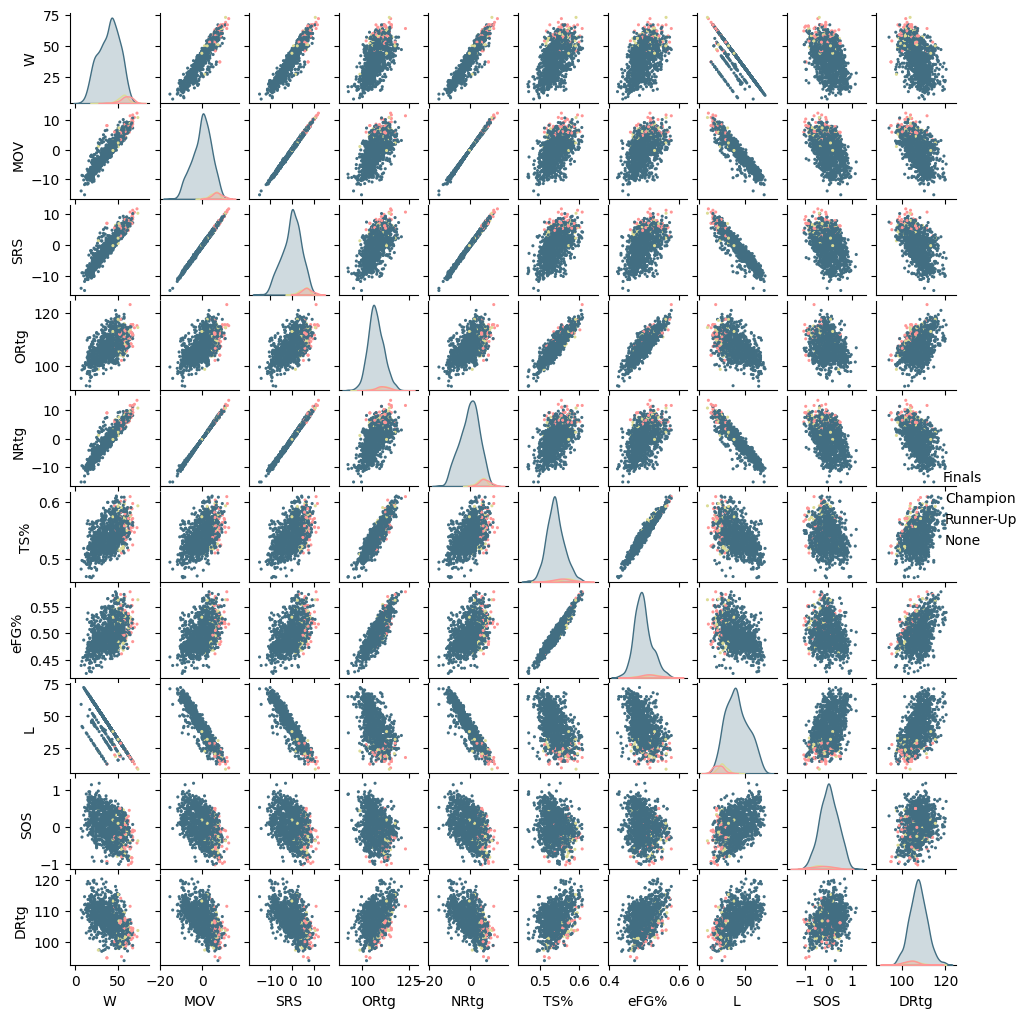

In [ ]:
cols = ['W', 'MOV', 'SRS', 'ORtg', 'NRtg', 'TS%', 'eFG%', 'L', 'SOS', 'DRtg', "Finals"]
pairplot_df = numeric_df.assign(Finals=numeric_df.apply(lambda row: 'Champion' if row['Champion'] else ('Runner-Up' if row['Runner-Up'] else 'None'), axis=1))

# Are my colors pretty?
palette = {
    "Champion": (255,150,150),
    "Runner-Up": (220,220,150),
    "None": (66,110,130)
}
palette_normalized = {key: tuple([x / 255 for x in value]) for key, value in palette.items()}

main_pairplot = sns.pairplot(pairplot_df[cols], 
                        hue='Finals', 
                        hue_order=["Champion", "Runner-Up", "None"],
                        palette=palette_normalized, 
                        height = 2, 
                        plot_kws={'s': 5, 'linewidth': 0.001}, 
                        diag_kind='kde')

main_pairplot.figure.set_size_inches(10, 10)

#### Pairplot of each category separated

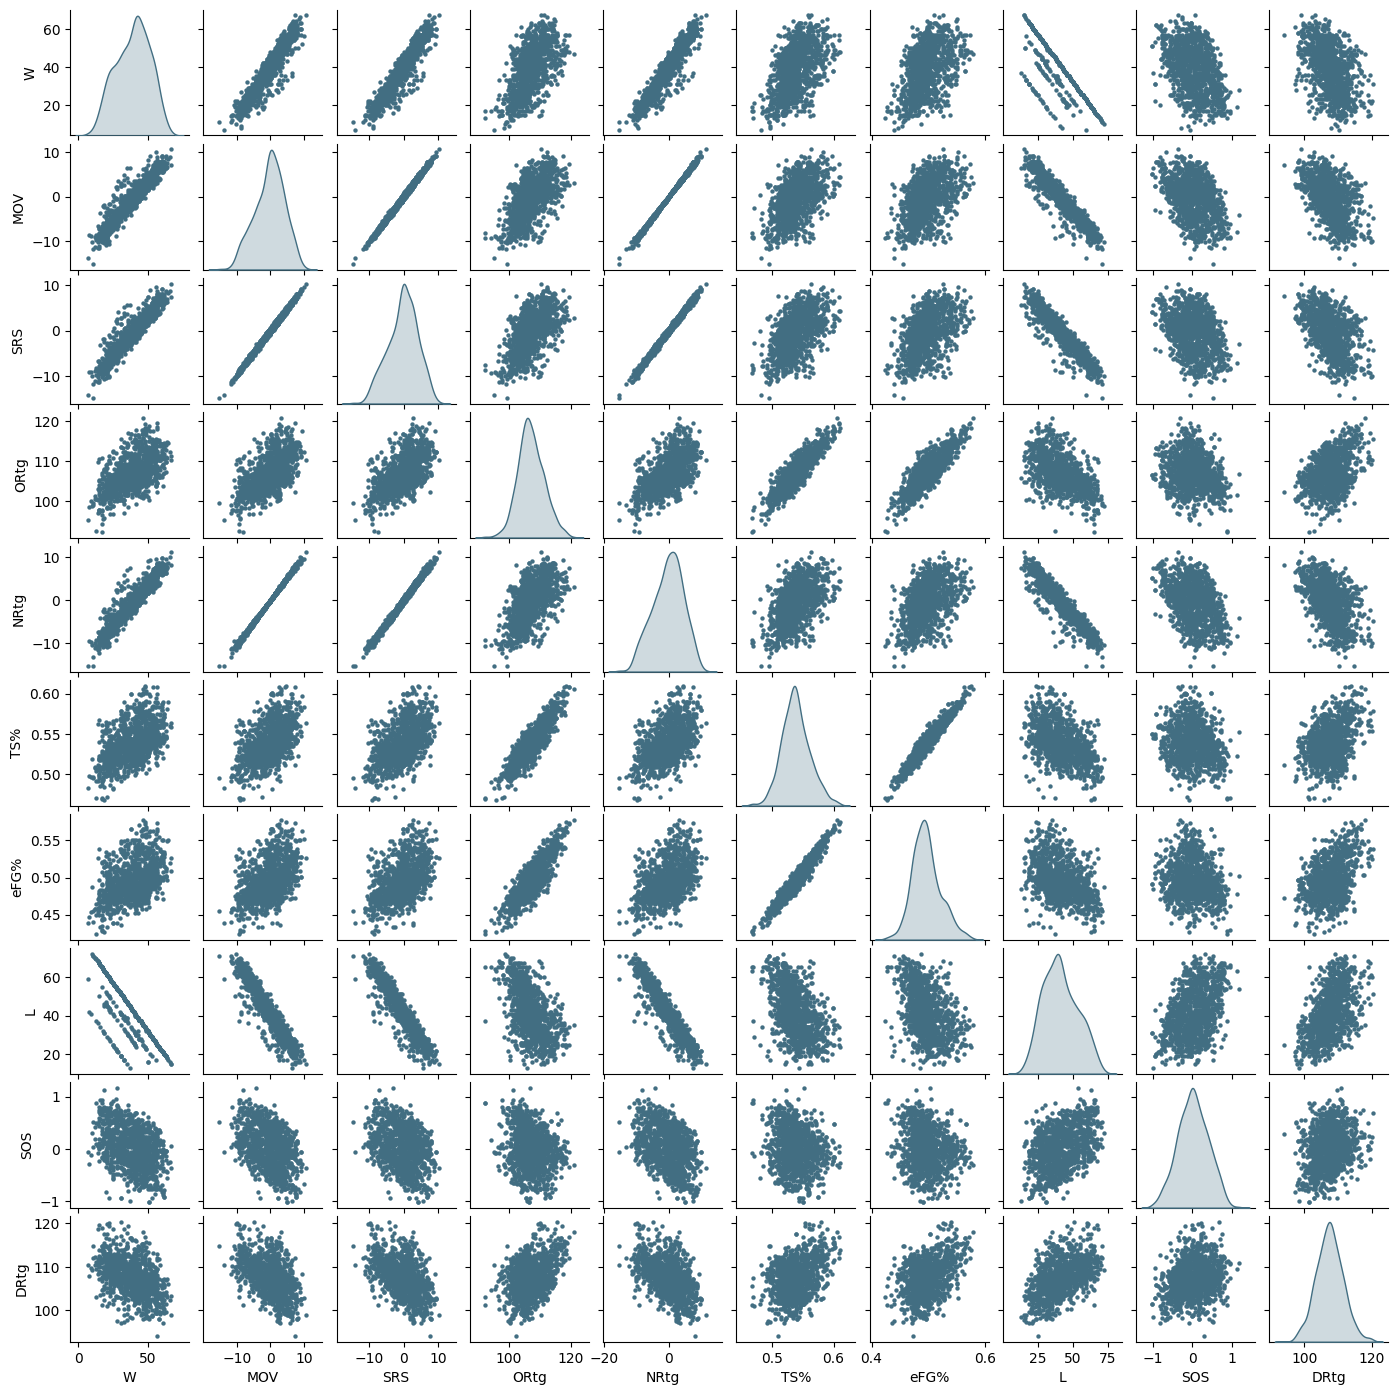

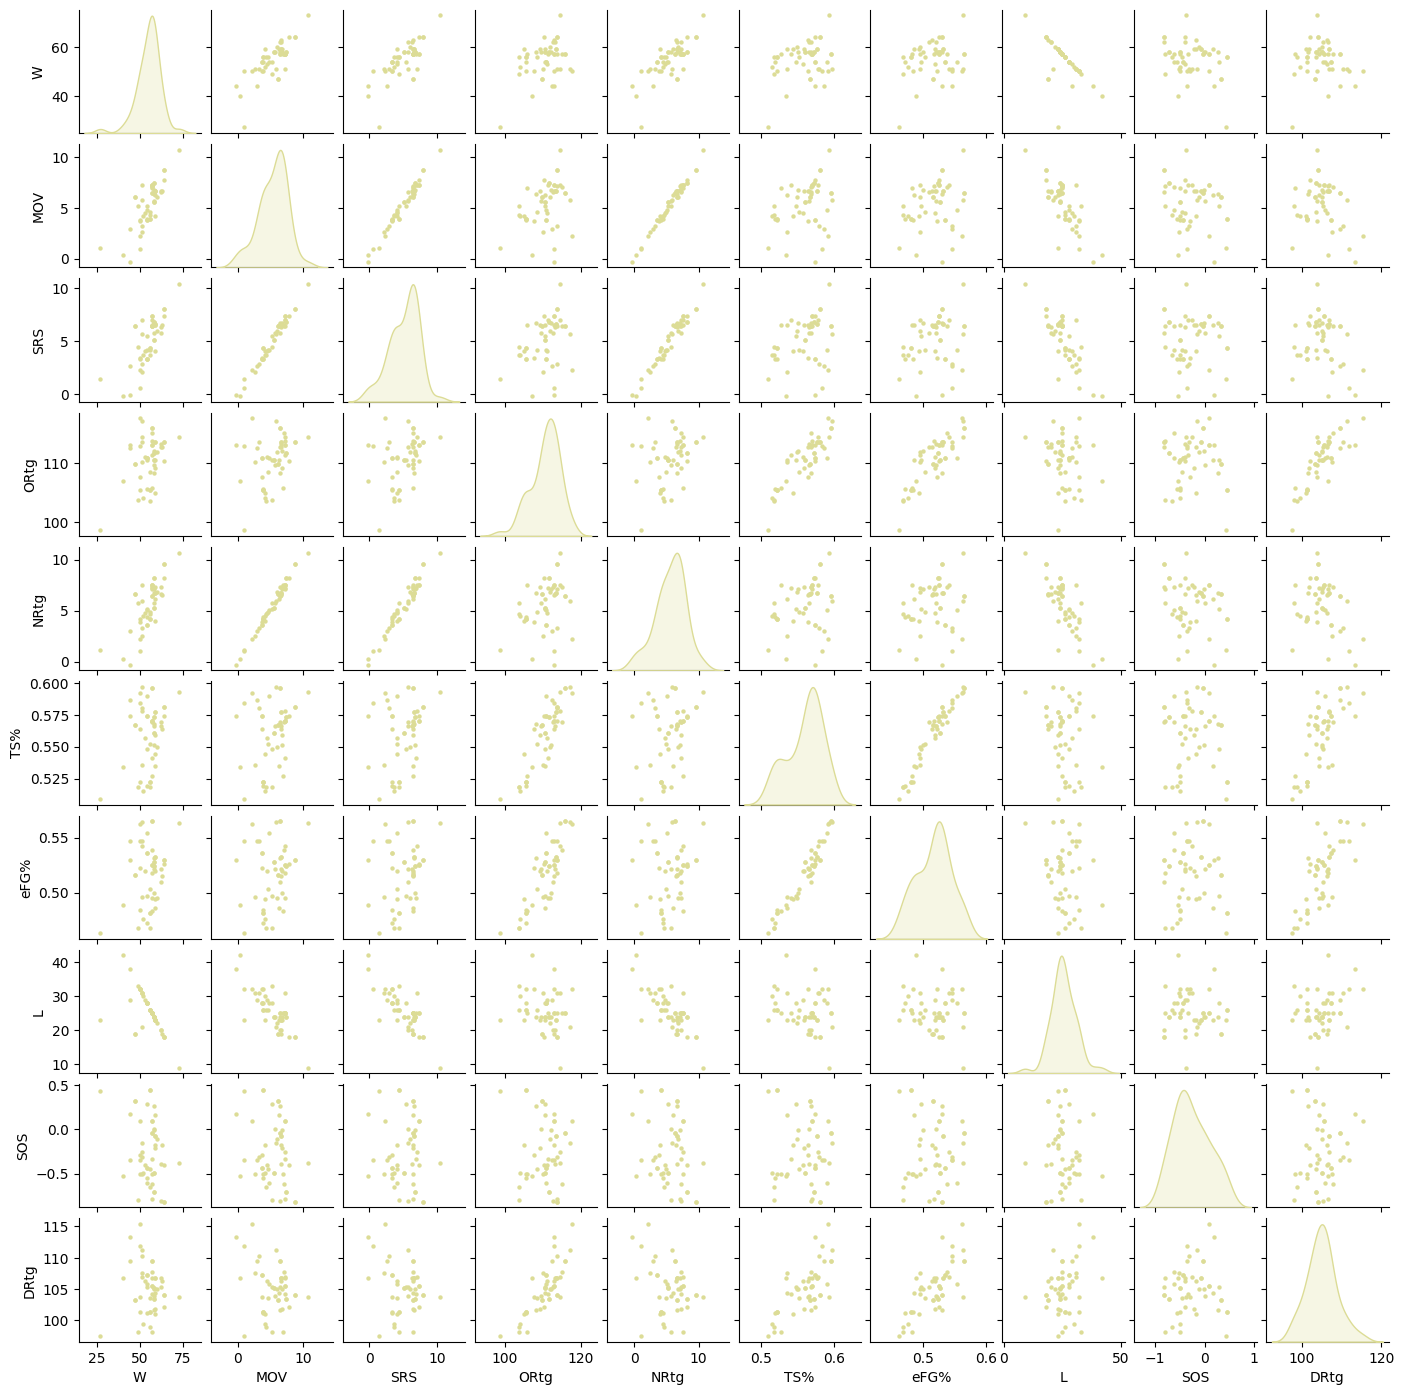

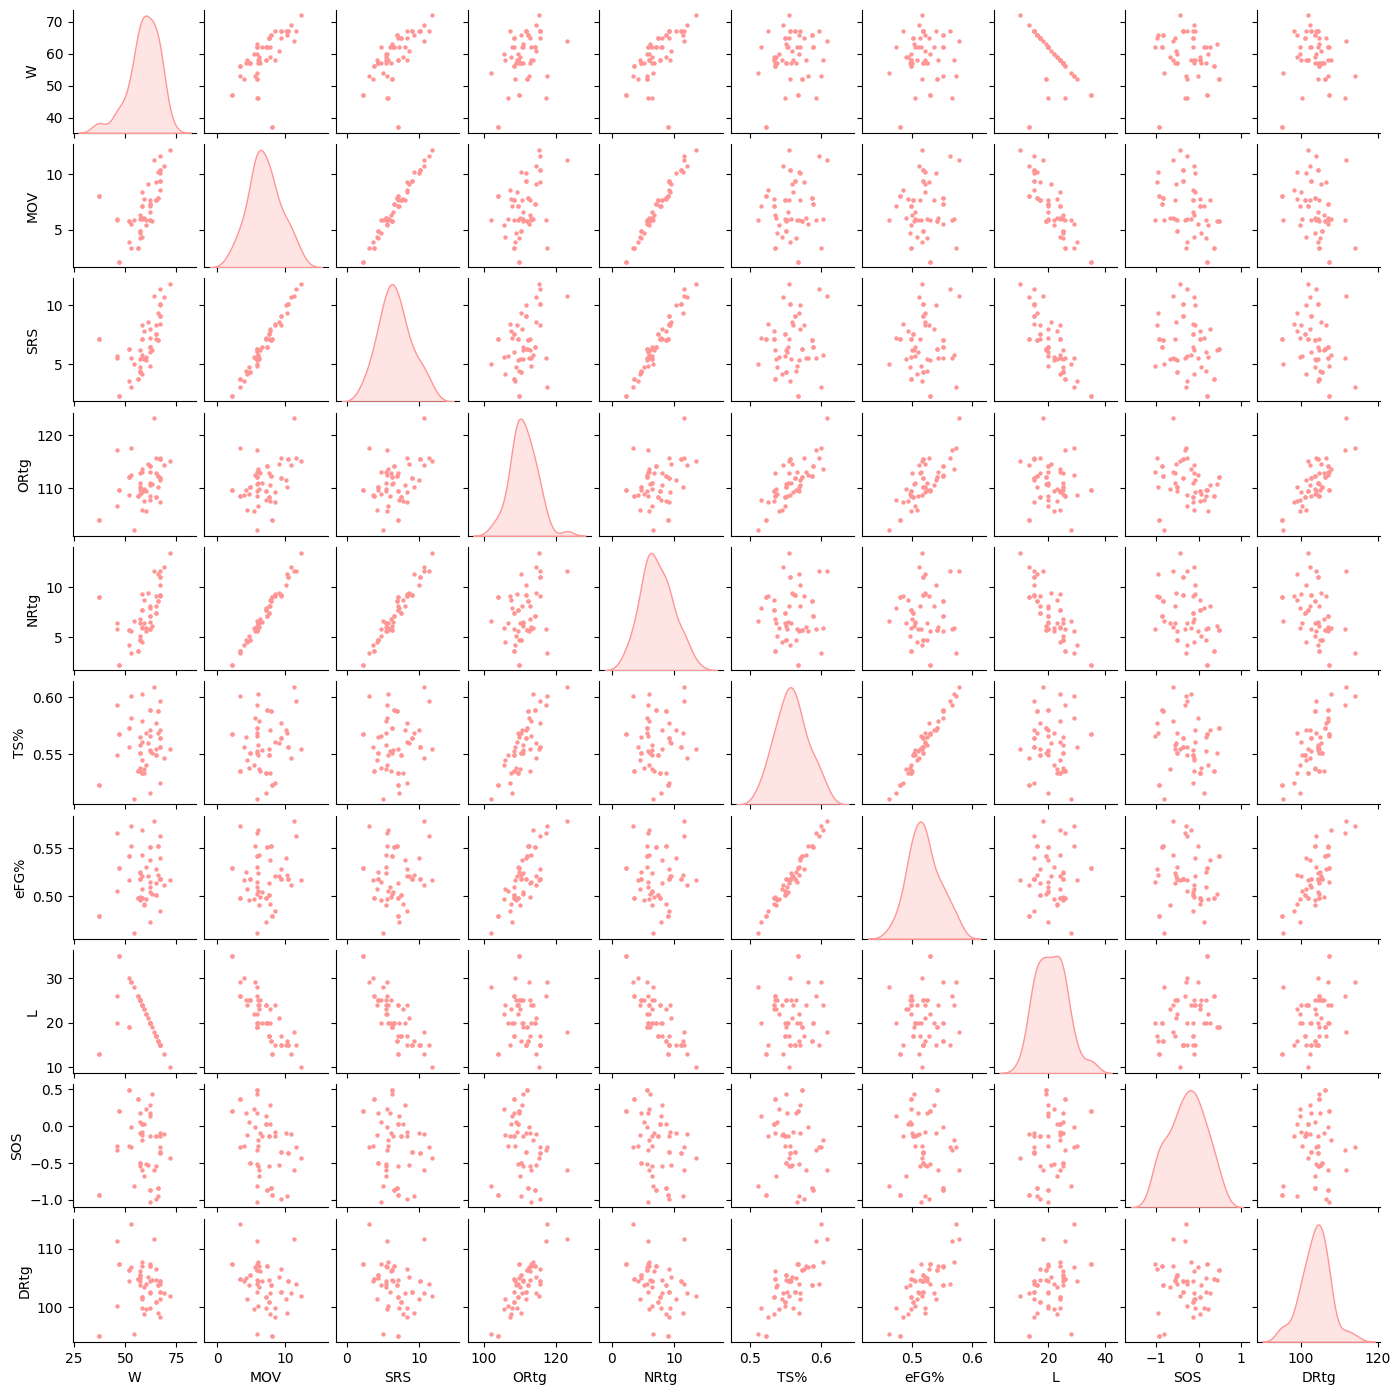

In [ ]:
finals = ["None", "Runner-Up", "Champion"]
for result in finals:
    plot = sns.pairplot(pairplot_df[pairplot_df["Finals"] == result][cols], 
        diag_kws={"color": palette_normalized[result]}, 
        height = 2, 
        plot_kws={'s': 10, 'linewidth': 0, "color": palette_normalized[result]}, 
        diag_kind='kde')
    plot.figure.set_size_inches(14, 14)

### Interpreting our visualizations
Even though these variables indicate a strong relationship with winning championships and becoming runner-ups, we feel that we may be undermining certain advanced statistics simply because they do not have a strong *linear* relationship.
- This is shown in the pairplots where the champions and runner-ups are not outliers in certain stats. And this may be attributed to generational differences.

We have decided to standardize the variables to account for generational differences.
- Different eras of basketball may have different playing styles and prefer certain strategies over others.
- To account for this, we will standardize the statistics relative to the year of those teams. This way, we can determine how **strong** these teams were during their era.

Lastly, moving forward, we have decided to "bring back" the variables previously dropped because of reasons such as weaker correlation in order to provide a more holistic and comprehensive analysis of these teams' abilities; we realized that linear relationships are unable to capture the essence of the story as indicated by these visualizations.
- By bringing back these features, they may improve accuracy of classification methods such as XGBoost even with lower correlation scores.
- In short, they may be a hidden gem.

In [3]:
main_df = pd.read_csv('main_df.csv')
main_df = main_df[main_df['Team'] != 'League Average']

## Standardizing true shooting, pace and 3 point rate relative to the year

In [4]:
# Define the columns to be transformed (excluding non-numeric columns as specified)
cols_to_transform = main_df.columns.difference([
    'Year', 'MOV', 'SOS', 'SRS', 
    'NRtg', 'Champion', 'Runner-Up', 'Top10PER', 'Team'
])

# Calculate the z-score for each numeric column within each 'Year' group
z_df = main_df.copy()
z_df[cols_to_transform] = main_df.groupby('Year')[cols_to_transform].transform(
    lambda x: (x - x.mean()) / x.std()
)



## Choosing the columns to keep and drop based on how well we think they predict the winners

In [5]:
# Define columns to exclude from the tests (non–z score columns)
exclude_cols = ['Team', 'Year', 'Champion', 'Runner-Up', 'Top10PER']

# Dictionary to store the test results for each column
results = {}

# Loop over each column in the DataFrame
for col in z_df.columns:
    if col not in exclude_cols:
        # Ensure the column is numeric (skip if not)
        if pd.api.types.is_numeric_dtype(z_df[col]):
            # Split data into champions and non-champions groups
            champions = z_df.loc[z_df['Champion'] == True, col]
            non_champions = z_df.loc[z_df['Champion'] == False, col]
            
            # Perform a t-test (using Welch's t-test by setting equal_var=False)
            t_stat, p_val = stats.ttest_ind(champions, non_champions, equal_var=False, nan_policy='omit')
            
            # Store the results along with the group means
            results[col] = {
                'mean_champion': champions.mean(),
                'mean_non_champion': non_champions.mean(),
                't_statistic': t_stat,
                'p_value': p_val,
                'significant': p_val < 0.05
            }

# Convert the results to a DataFrame for easier viewing
results_df = pd.DataFrame(results).T

In [6]:
results_df

,mean_champion,mean_non_champion,t_statistic,p_value,significant
W,1.451928,-0.064942,26.579405,0.0,True
L,-1.461341,0.065363,-26.710104,0.0,True
PW,1.388997,-0.062128,23.289875,0.0,True
PL,-1.397187,0.062494,-23.586137,0.0,True
MOV,6.96,-0.091821,20.734441,0.0,True
SOS,-0.267857,0.004081,-4.767038,0.000013,True
SRS,6.693036,-0.087684,20.990129,0.0,True
ORtg,1.087498,-0.048642,13.561533,0.0,True
DRtg,-1.065064,0.047639,-12.030961,0.0,True
NRtg,7.248214,-0.083227,20.288429,0.0,True


In [7]:
# Looking at the meadian of the winner vs the other for each stats
pd.set_option('display.max_columns', None)
main_df.drop(columns='Team').groupby('Champion')['Top10PER'].mean()

Champion
False    0.317891
True     0.839286
Name: Top10PER, dtype: float64

Based on the p-value these are the stats with a significant difference between the winners and the others:

'W, L, PW, PL, MOV, SOS,SRS,ORtg, DRTG, NRTG, TS%,eFG%,ORB%, DRB%, eFG%.1, FT/FGA.1, Top10PER'


Thw PW and PL columns will be dropped because it is highly correlated with W and L. Also eFG% will also be dropped because it tells the same story the TS% tells which is how efficient a team is at scoring.

In [8]:
final_df = main_df.drop(columns=['PW','PL','eFG%','Pace','FTr','3PAr','TOV%','FT/FGA','TOV%.1'])
finalZ_df = z_df.drop(columns=['PW','PL','eFG%','Pace','FTr','3PAr','TOV%','FT/FGA','TOV%.1'])

In [9]:
final_df.head()

,Team,W,L,MOV,SOS,SRS,ORtg,DRtg,NRtg,TS%,ORB%,eFG%.1,DRB%,FT/FGA.1,Year,Champion,Runner-Up,Top10PER
0,Boston Celtics,61.0,21.0,7.79,-0.42,7.37,109.4,101.9,7.5,0.550,34.8,0.475,67.8,0.234,1980,False,False,False
1,Los Angeles Lakers,60.0,22.0,5.90,-0.51,5.40,109.5,103.9,5.6,0.569,32.6,0.475,66.9,0.181,1980,True,False,True
2,Seattle SuperSonics,56.0,26.0,4.66,-0.42,4.24,105.8,101.2,4.6,0.520,36.4,0.463,67.9,0.221,1980,False,False,False
3,Philadelphia 76ers,59.0,23.0,4.22,-0.18,4.04,105.0,101.0,4.0,0.544,33.5,0.460,66.7,0.217,1980,False,True,True
4,Milwaukee Bucks,49.0,33.0,3.94,-0.37,3.57,106.8,102.9,3.9,0.532,35.2,0.467,63.8,0.229,1980,False,False,True


In [10]:
finalZ_df.head()

,Team,W,L,MOV,SOS,SRS,ORtg,DRtg,NRtg,TS%,ORB%,eFG%.1,DRB%,FT/FGA.1,Year,Champion,Runner-Up,Top10PER
0,Boston Celtics,1.603731,-1.603731,7.79,-0.42,7.37,1.755551,-1.101969,7.5,1.179443,0.625538,-0.674175,0.677860,-0.055568,1980,False,False,False
1,Los Angeles Lakers,1.523545,-1.523545,5.90,-0.51,5.40,1.797900,-0.447628,5.6,2.381900,-0.411313,-0.674175,0.213444,-2.145660,1980,True,False,True
2,Seattle SuperSonics,1.202798,-1.202798,4.66,-0.42,4.24,0.230994,-1.330988,4.6,-0.719173,1.379611,-1.434783,0.729462,-0.568232,1980,False,False,False
3,Philadelphia 76ers,1.443358,-1.443358,4.22,-0.18,4.04,-0.107797,-1.396422,4.0,0.799720,0.012854,-1.624935,0.110240,-0.725975,1980,False,True,True
4,Milwaukee Bucks,0.641492,-0.641492,3.94,-0.37,3.57,0.654482,-0.774799,3.9,0.040274,0.814056,-1.181247,-1.386212,-0.252747,1980,False,False,True


# Choosing predictors
Determining how much a feature contributes to an outcome is crucial in predictive modeling, and there are numerous methods in doing so. One common approach is using classification trees, which measure impurity reduction at each split. The greater the impurity reduction, the more influential the feature is in predicting the target variable.

We can expand on this idea and utilize more robust methods. For example, ensemble methods such as XGBoost or AdaBoost. A major trade-off of this method is interpretability of the tree. However, we will worry about that afterwards. And we will be using XGBoost as AdaBoost aggressively attempts to re-weigh outliers, which are central to this project. Another reason is that XGBoost simply works better with larger and noisier datasets (and our data is exactly that).

In [11]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score

In [70]:
# These are the features that remained after multiple rounds of selecting
predictors = ["MOV", "SOS", "SRS", "ORtg", "DRtg", "NRtg", "TS%", "ORB%", "eFG%.1", "DRB%", "FT/FGA.1", "Top10PER"]
X = finalZ_df[predictors]
y = finalZ_df["Champion"]

Preparing Data We select the predictor features (based on prior selection rounds) and the target variable ("Champion") from the DataFrame `finalZ_df`. This separates the features (X) from the labels (y) for subsequent training.

In [71]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Initialize the XGBoost classifier with a max depth of 4 and a specified evaluation metric
model = XGBClassifier(eval_metric="merror", max_depth=4)

# Train the model using the training data
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='merror',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

 Splitting Data and Training the Model - **Data Split:** The dataset is split into training (80%) and testing (20%) sets to enable model evaluation. - **Model Initialization:** An XGBoost classifier is created with a maximum tree depth of 4 and the evaluation metric set to "merror". - **Model Training:** The classifier is trained using the training subset.

In [72]:
# Predict on the test set (which includes both champions and non-champions)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9885496183206107


The following accuracy score is *not* the model's ability to predict champions as it accounts for ability to classify non-champions as well, which we have significantly more data for.

 Evaluating Overall Model Accuracy - **Prediction:** The model predicts the labels for the test set. - **Accuracy Calculation:** The accuracy score is computed over the entire test set, reflecting the model's performance across all classes (champions and non-champions). 

In [73]:
# Evaluate model accuracy specifically on the champion instances from the entire dataset
champions_df = finalZ_df[finalZ_df["Champion"] == True]
X_champions = champions_df[predictors]
y_champions = champions_df["Champion"]

y_pred_champions = model.predict(X_champions)
accuracy = accuracy_score(y_champions, y_pred_champions)
print("Accuracy (in predicting champions):", accuracy)

Accuracy (in predicting champions): 0.9642857142857143


Evaluating Champion Prediction Accuracy on Full Dataset - **Subset Extraction:** We filter the full dataset to include only rows where the team is a champion. - **Prediction & Accuracy:** The model predicts and the accuracy is computed for these champion cases, measuring how well it can detect champions overall.

In [74]:
# Evaluate model accuracy for champions within the test set
X_test_champions = X_test[y_test]
y_pred_test_champions = model.predict(X_test_champions)
accuracy = accuracy_score(y_test[y_test == True], y_pred_test_champions)
print("Accuracy (in predicting champions test on testing set):", accuracy)

Accuracy (in predicting champions test on testing set): 0.6666666666666666


Run this over many trials without fixed random state to see if results happened by chance.

In [82]:
model = XGBClassifier(eval_metric="merror", max_depth=4)

def simulate(model, trials: int = 10):
    predictions = np.zeros(trials)

    for i in range(trials):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
        X_test_champions = X_test[y_test]
        model.fit(X_train, y_train)
        
        y_pred_test_champions = model.predict(X_test_champions)
        accuracy = accuracy_score(y_test[y_test == True], y_pred_test_champions)

        predictions[i] = accuracy

    return np.mean(predictions)

print("Average prediction accuracy:", simulate(model, 100))

Average prediction accuracy: 0.42896078830869855


This is basically as good as a coin toss (actually even worse) so we need to improve the model.

 Evaluating Champion Prediction Accuracy on Testing Set - **Test Subset for Champions:** From the test set, only the samples where the actual label is `True` (champions) are selected. - **Prediction & Accuracy:** The accuracy is then calculated for these samples to specifically assess performance on champion predictions within the test data. 

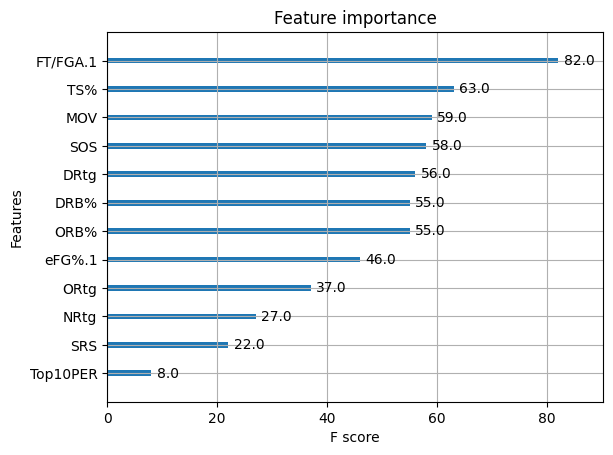

In [17]:
# Plot feature importance
xgb.plot_importance(model)
plt.show()

Plotting Feature Importance This block generates a plot to visualize the importance of each feature in the trained model. It helps identify which features most significantly affect the prediction outcome.

### Using a grid search and cross validation to see if the model improves
Re-initializing the Model for Hyperparameter Tuning 
- **Model Re-initialization:** This time, we will stratify the data to ensure there's an equal amount of champions represented in both the training and testing set. Since we don't have many champions compared to non-champions, our data set is highly imbalanced and this would help ensure that we have champions to work with on both the training and testing.

In [ ]:
# Using a grid search and cross validation to see if the model improves
# NOTE: Re-initialized the model and tested with logloss and merror and aucpr
# AUCPR (Area Under the Precision-Recall Curve) works great with imbalanced datasets
model = XGBClassifier(eval_metric="aucpr")
# NOTE: We stratify here since champions are rare
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

In [108]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

scale_pos_weight = 22.2


Since we have very little champions compared to champions, we need to correct this imbalance.

In [109]:
# Define the hyperparameter grid to search
param_grid = {
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.3, 0.5, 0.7],
    'n_estimators': [50, 100, 200, 300],
    'subsample': [0.4, 0.6, 0.8, 1.0],
    'colsample_bytree': [0.4, 0.6, 0.8, 1.0],
    'scale_pos_weight': [scale_pos_weight, scale_pos_weight*2],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 2]
}

# Set up 5-fold stratified cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Set up GridSearchCV to search for the best hyperparameters
grid_search = GridSearchCV(estimator=model,
                           param_grid=param_grid,
                           scoring='average_precision',
                           cv=cv_strategy,
                           n_jobs=-1,
                           verbose=1,
                           error_score='raise'
                           )

# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 9216 candidates, totalling 46080 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             error_score='raise',
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='aucpr', feature_types=None,
                                     gamma=None, grow_poli...
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.4, 0.6, 0.8, 1.0],
                         'gamma': [0, 0.1, 0.2],
                         'learning_rate': [0.01, 0.3, 0.5, 0.7],
                         'max_depth': [3, 4, 6], 'min_child_weight': [1, 2],
                         'n_estimators': [50, 100, 200, 300],
                         'scale_pos_weight': [np.float64(22.244444444444444),
                                              np.float64(44.48888888888889)],
                         'subsample': [0.4, 0.6, 0.8, 1.0]},
             scoring='average_precision', verbose=1)

Defining the Hyperparameter Grid 
- **Hyperparameter Ranges:** We create a dictionary that lists multiple potential values for key parameters such as tree depth, learning rate, number of estimators, subsample ratio, and column sample ratio. 
- This grid will be explored during the grid search to find the best model configuration.

Setting Up Cross-Validation Strategy 
- **StratifiedKFold:** We use a stratified 5-fold cross-validation to ensure that each fold maintains the same class proportions, which is especially important for imbalanced datasets.

Performing Grid Search with Cross-Validation 
- **GridSearchCV Configuration:** The grid search is set up to explore all combinations in the hyperparameter grid using the stratified cross-validation strategy. 
- **Scoring Metric:** The scoring is based on `average_precision`, which is crucial for detecting champions (positive class) especially when data is imbalanced. We also tested with `recall`, but it did not generalize as well so we ended up going with `average_precision`.
- **Fitting:** The grid search is executed on the training data to determine the best hyperparameter configuration. 

In [110]:
# Output the best parameters and best cross-validation score
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: {:.4f}".format(grid_search.best_score_))

# Evaluate the best estimator on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Test set accuracy: {:.4f}".format(accuracy))

X_test_champions = X_test[y_test]
y_pred_test_champions = best_model.predict(X_test_champions)
accuracy = accuracy_score(y_test[y_test == True], y_pred_test_champions)

print("Accuracy (in predicting champions test on testing set):", accuracy)

Best parameters found:  {'colsample_bytree': 0.6, 'gamma': 0.1, 'learning_rate': 0.3, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 100, 'scale_pos_weight': np.float64(44.48888888888889), 'subsample': 0.4}
Best cross-validation accuracy: 0.5898
Test set accuracy: 0.9771
Accuracy (in predicting champions test on testing set): 0.5454545454545454


In [113]:
print("Average accuracy (in predicting champions test on testing set):", simulate(best_model, 100))

Average accuracy (in predicting champions test on testing set): 0.5504955052257684


Not very stellar! But it's better than a coin toss. And the cross-validation accuracy appears to be fair as well. Lastly, let's see how the feature importance changed.

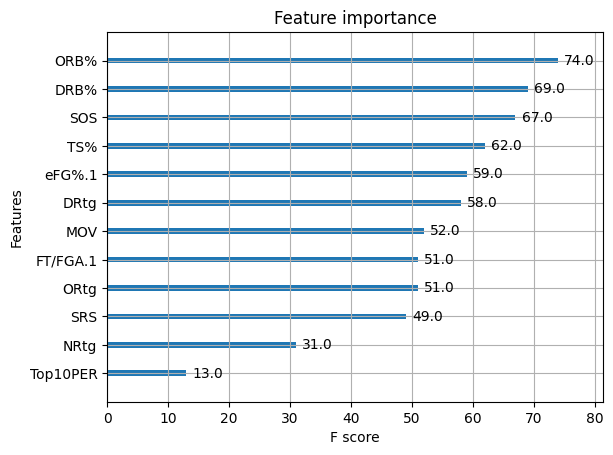

In [116]:
# Plot feature importance
xgb.plot_importance(best_model)
plt.show()

Reporting Grid Search Results 
- **Best Parameters:** The optimal hyperparameter combination discovered by the grid search is printed. 
- **Cross-Validation Score:** The corresponding best cross-validation score is also displayed to show model performance during tuning.

Evaluating the Tuned Model 
- **Test Evaluation:** The best estimator from the grid search is used to predict the test set, and overall accuracy is calculated. 
- **Champion-Specific Evaluation:** Additionally, the model's performance in predicting champions (true positives) within the test set is computed. 
- This two-step evaluation helps to assess the improvement brought by hyperparameter tuning.

# Ethics & Privacy

Our data consists of team statistics from 1980-2024 through a publicly available dataset, Basketball Reference. Since this data represents a team and not individuals, there is little personally identifiable information. The method of obtaining this data follows guidelines for research and analysis, which reduces problems regarding player consent or sensitive info. Some potential biases in our dataset is that it includes stats from teams with injuries. 

This could negatively impact a team’s rating but isn’t reflected in the set. Another bias is rule changes throughout the years, which could improve or reduce from certain team ratings. To combat this problem, we will set out to look for rule changes or unique team situations that may impact particular stats. Another factor that may skew the data is pace. The pace of the game was slower early on and has gotten faster in recent years. To account for this, we will focus on stats per possession as eras with more possessions won’t have an intrinsic advantage than those with less.

# Discusison and Conclusion

Below is a concise overview of the modeling process, results, and interpretation of the XGBoost classifier used to predict whether a team is a champion.

---

## 1. Model Overview

We used an **XGBoost (XGBClassifier)** to predict a binary outcome: whether a team is a champion (`Champion = True`) or not (`Champion = False`). The features included metrics such as offensive/defensive ratings, rebounding percentages, efficiency metrics, and others derived from the dataset.

**Key Steps:**
1. **Data Splitting:** We split the data into training (80%) and test (20%) sets.
2. **Model Training:** An initial XGBoost model was fit on the training data using default or modest hyperparameters.
3. **Evaluation Metrics:**
   - **Overall Accuracy** on the test set (includes both champions and non-champions).
   - **Champion Accuracy** on:
     - The entire dataset’s champion entries (how well the model classifies champions in the full data).
     - Only the test set’s champion entries (reflects real-world, unseen data performance for the champion class).
4. **Hyperparameter Tuning (Grid Search):** A grid search with 5-fold stratified cross-validation was performed to optimize hyperparameters (e.g., `max_depth`, `learning_rate`, `n_estimators`, `subsample`, `colsample_bytree`).

---

## 2. Initial XGBoost Model Results

1. **Overall Test Set Accuracy:** `0.9809`  
   This high accuracy indicates that for both champions and non-champions combined, the model predicts correctly about 98% of the time.

2. **Champion Accuracy (Full Dataset):** `0.9642`  
   When we look at all champions in the dataset, the model is correct roughly 96% of the time. This includes both training and test data, so it can be somewhat optimistic due to the model having already seen part of the data.

3. **Champion Accuracy (Test Set Only):** `0.6667` and `less than 0.5` in the long run  
   On truly unseen champion data in the test set, the model’s accuracy is about 66.7%. This is may appear to be a strong indicator of performance for identifying new champion cases, but it's not, especially when considering that many simulations of the model resulted in an average accuracy of approximately 45% - meaning it's worse than a coin toss!

---

## 3. Hyperparameter Tuning and Results

A **GridSearchCV** was conducted to refine the model’s hyperparameters. The final best parameters identified were:







### Cross-Validation Performance

- **Best Cross-Validation Score (Recall)**: `0.5898`  

  *Note:* The reported “best cross-validation accuracy” in the output is actually based on the specified scoring metric (`average_precision`). This indicates that on average, the model recalled about 58% of the positive class (champions) across the cross-validation folds.

### Test Set Performance with Tuned Model

1. **Overall Test Set Accuracy:** `0.9771`  
   A slight decrease over the original model’s 0.9809, confirming that tuning helped the model better generalize to the test data overall (less overfitting).

2. **Champion Accuracy (Test Set Only):** `0.5455`  
   The champion-specific accuracy on the test set improved (54.55%), indicating that the overall accuracy improved, the model’s ability to correctly identify champions in unseen data is better compared to untuned, which was worse than a coin toss (<50%).

---

## 4. Feature Importance

Below is the feature-importance chart from the original XGBoost model (without hyperparameter tuning):

1. **FT/FGA.1** – Shown as the most influential feature (score ~77.0).  
2. **ORB%** – Offensive rebounding percentage (~58.0).  
3. **TS%** – True shooting percentage (~56.0).  
4. **SOS** – Strength of schedule (~56.0).  
5. **DRB%** – Defensive rebounding percentage (~53.0).  
6. **DRtg** – Defensive rating (~49.0).  
7. **ORtg** – Offensive rating (~48.0).  
8. **MOV** – Margin of victory (~46.0).  
9. **eFG%.1** – Effective field goal percentage (~46.0).  
10. **NRtg** – Net rating (~25.0).  
11. **SRS** – Simple rating system (~23.0).  
12. **Top10PER** – Proportion of top players in PER (~10.0).

These results suggest that **free-throw attempts relative to field-goal attempts**, **offensive rebounding**, **true shooting percentage**, and **strength of schedule** are among the most influential metrics in differentiating champion vs. non-champion teams (in the initial model). Even if the grid-searched model might differ slightly, these features generally stand out as important.

What is most strikingly significant is that offensive rebounding percentage (ORB) appears to be a strong feature for **both** models. There may be something unique or impactful about this statistic and it may be an important difference maker in whether a team wins or loses.

---

## 5. Interpretation

- **High Overall Accuracy vs. Lower Champion Accuracy**  
  The dataset has many more non-champion examples, so the model excels in identifying non-champions (leading to a high overall accuracy) but is more challenged in consistently labeling champions. A 54.55% accuracy for champions in the test set means that our model is only slightly better than a coin toss in the long run.

---

### Conclusion

- **Overall Performance**: The XGBoost model, both before and after hyperparameter tuning, exhibits excellent overall accuracy (~97%+).  
- **Champion Detection**: The champion detection rate on unseen data remains around 54.55%.  
- **Feature Importance**: **FT/FGA.1**, **ORB%**, **TS%**, and **SOS** are among the most important features in determining champion status in the original model.  

Further techniques focusing on improving recall for the champion class should be explored. Nonetheless, the current model already provides a strong baseline for overall classification.


# Team Contributions

Speficy who did what.  This should be pretty granular, perhaps bullet points, no more than a few sentences per person.

Borngreat Omoma-Edosa:
- I worked on the describing the data collection process and mining the data
- I worked on the second half of the EDA, specifiaclly standardizing the dataset and figuring out the significant features and the feature that are very similar
- I worked on implementing the gridsearch to see if we could find better hyperparameter to improve the model

Adrian
- I made the Background and Prior Work and Hypothesis
- I worked on the video
- I worked on the initial webscraping of the data 

Steven 
- Worked on cleaning and wrangling data.
- Worked on most of the data visualizations.
- Worked on implementing and refining the XGBoost model.

Dominic
- I worked on the Ethics and Privacy
- I worked on the video
- I worked on the Abstract
- Helped with checkpoint organization / writing